In [1]:
import os
import sys
%matplotlib inline
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_notebook import *

n_samples_test = 1000
project_name = "syn"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

experiment_names = ['basic_biased_00', 'test_biased_80', 'test_biased_80_switch_300',"shape_biased_00", "good_model_0_biased_00"]

In [2]:

all_series = []
all_stats = []

with total_silence():
    for experiment_name in experiment_names:
        stats = get_stats(project_name, experiment_name, n_samples_test, split='test')
        all_stats.append(stats)
        s = get_global_metrics_series(experiment_name, stats)
        all_series.append(s)

    comparison_df = pd.concat(all_series, axis=1)
    all_stats_series = pd.Series(all_stats, index = experiment_names)

In [3]:
# Accuracy (Classification par couleur) : Mesure la fidélité de la traduction "Attributs -> v_latents".
# On compare les catégories réelles aux catégories prédites à partir des images reconstruites par la traduction "Attributs -> v_latents".
# La classification repose exclusivement sur la moyenne R, G, B des pixels colorés (exclusion des pixels noir et blancs) de l'image reconstruite.

# Color constrat: Indice d'intensité de l'effet mesuré par le test non paramétrique de Kruskal-Wallis. 
# Ce test évalue si au moins un des canaux prédomine significativement sur les autres, (écar au gris ou R=G=B).
# La métrique utilisée est l'Epsilon-carré (ϵ2), qui normalise la statistique H du test entre 0 (aucune différence, image grise) et 1 (différence maximale, couleur saturée).
# Le score global est la moyenne des ϵ2 obtenus pour chaque catégorie.

# Demi-cycle v_latents loss et Demi-cycle Attr loss: la loss de demi cycle à la dernière epoch

display(comparison_df)

,basic_biased_00,test_biased_80,test_biased_80_switch_300,shape_biased_00,good_model_0_biased_00
Accuracy category classification by color,0.540000,1.000000,0.780000,0.835000,0.990000
Color contrast,0.003620,0.675478,0.015343,0.531559,0.286546
Demi-cycle v_latents loss,0.031248,0.022695,0.023964,0.016438,0.022004
Demi-cycle Attr loss,0.003986,0.003118,0.002904,0.002880,0.003703


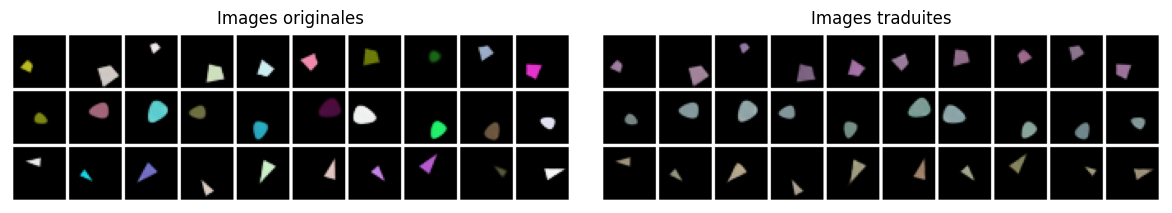

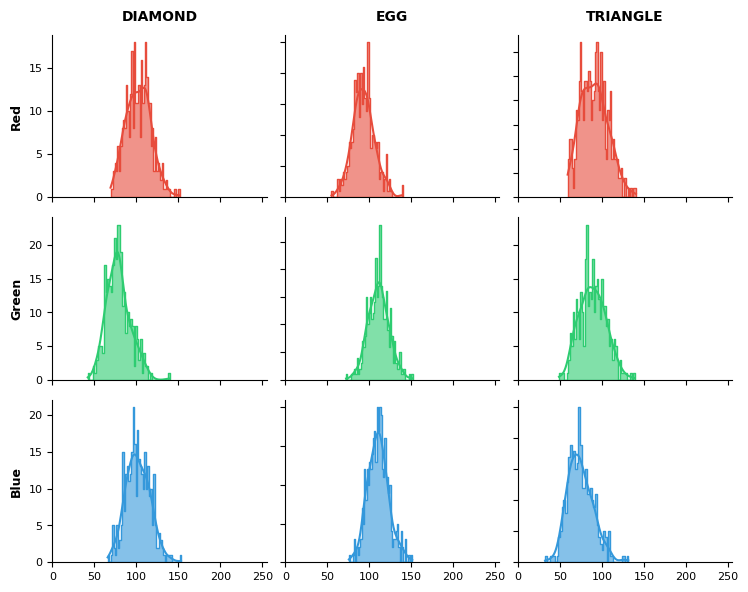

In [5]:
check_run = "good_model_0_biased_00"

display(all_stats_series[check_run]["fig_original_translated"])
display(all_stats_series[check_run]["fig_rgb_distrib"])